### Exercise 3: Grids

**a) How many numbers need to be stored to fully specify a scalar field on a uniform grid of size 10 x 10 x 10 (including the data itself)? Why?**

A uniform grid of size 10 x 10 x 10 has 1000 points (10 * 10 * 10 = 1000).
For a scalar field, we store 1 number for each point. So, we need **1000 numbers** for the data.

To fully describe the grid (since its size 10x10x10 is already known), we also need to store its geometry:
- **3 numbers** for the starting point (origin: x, y, z).
- **3 numbers** for the distance between points (spacing: dx, dy, dz).

**Total:** 1000 + 3 + 3 = **1006 numbers**.

**b) How many cells does the grid from a) contain?**

A grid with 10 points in each direction (x, y, z) has 9 spaces (or cells) between these points in each direction.
So, the number of cells is 9 x 9 x 9.

**Total cells:** 9 * 9 * 9 = **729 cells**.

**c) How many *additional* numbers need to be stored if the same grid is specified in more general form as a rectilinear grid?**

In a rectilinear grid, the distance between points can change. We cannot just use one spacing value per direction.
Instead, we must save the exact position of every row, column, and layer.
- X-axis positions: 10 numbers
- Y-axis positions: 10 numbers
- Z-axis positions: 10 numbers
**Total for positions:** 30 numbers.

In a uniform grid, we only used 6 numbers for origin and spacing.
**Additional numbers needed:** 30 - 6 = **24 numbers**.

**d) Sketch a domain on which you would rather use an unstructured than a structured grid.**

A structured grid is good for simple shapes.
An unstructured grid is better for complex, curved shapes, or shapes with holes inside.

Here is an example sketch using Python: a shape with a hole inside.

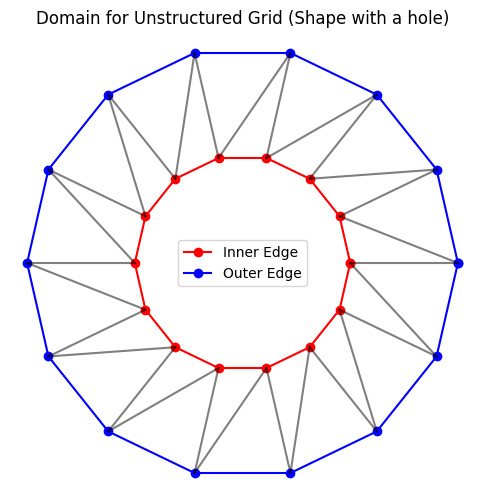

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Draw a shape with a hole (annulus) to show a complex domain
angles = np.linspace(0, 2*np.pi, 15)
r_inner = 1
r_outer = 2

# Points for the grid
inner_x = r_inner * np.cos(angles)
inner_y = r_inner * np.sin(angles)
outer_x = r_outer * np.cos(angles)
outer_y = r_outer * np.sin(angles)

plt.figure(figsize=(6, 6))

# Draw the boundaries
plt.plot(inner_x, inner_y, 'ro-', label='Inner Edge')
plt.plot(outer_x, outer_y, 'bo-', label='Outer Edge')

# Draw lines to show triangles (unstructured grid)
for i in range(len(angles)-1):
    plt.plot([inner_x[i], outer_x[i]], [inner_y[i], outer_y[i]], 'k-', alpha=0.5)
    plt.plot([inner_x[i+1], outer_x[i]], [inner_y[i+1], outer_y[i]], 'k-', alpha=0.5)

plt.title("Domain for Unstructured Grid (Shape with a hole)")
plt.legend()
plt.axis('equal')
plt.axis('off') # Hide the box to focus on the shape
plt.show()

As we can see in the image above, an **unstructured grid** (made of triangles) is much better for this shape. It can easily fit the curved edges and the empty hole in the middle. A structured grid (like a grid of squares) would not fit this circular shape perfectly.